In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.models import LinearRegression
from src.utils import load_data
from src.preprocessing import area_units_conversion

dir_base = "data/processed/"



train_path = dir_base + "casas_train_filled.csv"
validation_path = dir_base + "casas_val_filled.csv"
test_path = dir_base + "casas_test_filled.csv"

already_scaled = False

def use_test(test_path, is_scaled=False, train_stats=None):
    test = pd.read_csv(test_path)
    test = area_units_conversion(test)
    # if is_scaled:
    #    test = scale_df(test, train_stats, True)
       
    return test

test = use_test(test_path)

features = ["area", "is_house", "has_pool", "age", "lat", "lon", "rooms"] 
target = "price"

X_train, y_train = load_data(train_path, None, features, target)
X_val, y_val = load_data(validation_path, None, features, target)
X_test, y_test = load_data("", test, features, target, True)

model_multi_pinv = LinearRegression(X_train, y_train, X_val, y_val, features)
model_multi_pinv.entrenar_pseudoinversa()
model_multi_pinv.evaluar(X_test, y_test)


Error cuadrático medio (MSE) en test: 12373.5585


12373.558474124568

            count      mean
cluster_id                 
0             367  4.671766
1             353  2.659845


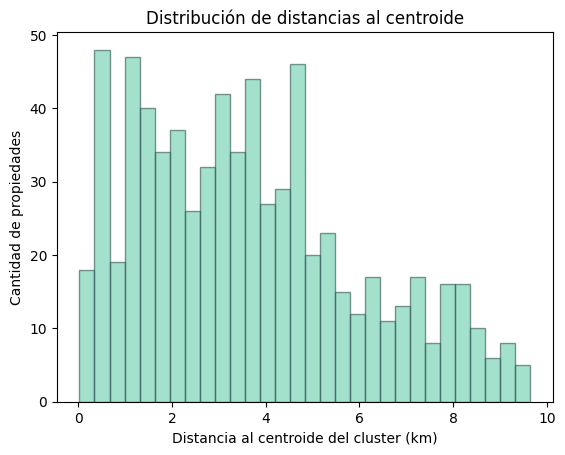

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


casas_train_df = pd.read_csv(train_path)
casas_val_df = pd.read_csv(validation_path)
casas_test_df = pd.read_csv(test_path)

lat_lon_train = casas_train_df[['lat', 'lon']].values
lat_lon_val = casas_val_df[['lat', 'lon']].values
lat_lon_test = casas_test_df[['lat', 'lon']].values

# Inicialización de centroides
np.random.seed(42)
centroids = lat_lon_train[np.random.choice(len(lat_lon_train), 2, replace=False)]

from Tissera_AnaPaula_TP1.src.feature_engineering import kmeans, assign_to_cluster

# K-Means
train_labels, final_centroids = kmeans(lat_lon_train, k=2) # los centroides se calculan con train
centroids_dict = {i: final_centroids[i] for i in range(2)}

val_labels = np.array([assign_to_cluster(p, centroids_dict) for p in lat_lon_val])
test_labels = np.array([assign_to_cluster(p, centroids_dict) for p in lat_lon_test])


casas_train_df['cluster_id'] = train_labels
casas_val_df['cluster_id'] = val_labels
casas_test_df['cluster_id'] = test_labels

from Tissera_AnaPaula_TP1.src.feature_engineering import distance_to_centroid

train_distances = distance_to_centroid(train_labels, lat_lon_train, centroids_dict)
val_distances = distance_to_centroid(val_labels, lat_lon_val, centroids_dict)
test_distances = distance_to_centroid(test_labels, lat_lon_test, centroids_dict)


casas_train_df['dist_to_cluster_centroid'] = train_distances
casas_val_df['dist_to_cluster_centroid'] = val_distances
casas_test_df['dist_to_cluster_centroid'] = test_distances

# Resumen de clusters
train_clusters_summary = casas_train_df.groupby("cluster_id")['dist_to_cluster_centroid'].agg(['count', 'mean'])
train_clusters_summary = train_clusters_summary[train_clusters_summary['count'] > 0]
print(train_clusters_summary)

plt.hist(casas_train_df['dist_to_cluster_centroid'].dropna(), bins=30, color="mediumaquamarine", edgecolor="darkslategrey", alpha=0.6)
plt.xlabel("Distancia al centroide del cluster (km)")
plt.ylabel("Cantidad de propiedades")
plt.title("Distribución de distancias al centroide")
plt.show()


binarias

In [3]:
median_distance = casas_train_df['dist_to_cluster_centroid'].median()

casas_train_df['is_near_centroid'] = (casas_train_df['dist_to_cluster_centroid'] < median_distance).astype(int)
casas_val_df['is_near_centroid'] = (casas_val_df['dist_to_cluster_centroid'] < median_distance).astype(int)
casas_test_df['is_near_centroid'] = (casas_test_df['dist_to_cluster_centroid'] < median_distance).astype(int)

casas_train_df[['dist_to_cluster_centroid', 'is_near_centroid']].head()


,dist_to_cluster_centroid,is_near_centroid
0,1.064317,1
1,0.588810,1
2,5.890130,0
3,3.772768,0
4,5.341236,0


In [4]:
def hist_plot(df, column):
    plt.figure(figsize=(4, 2))
    sns.histplot(df[f"{column}"], bins=50, kde=True)
    plt.title(f"Distribución de {column}")
    plt.show()

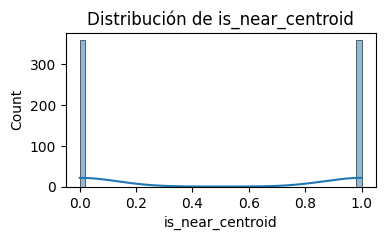

In [5]:
hist_plot(casas_train_df, 'is_near_centroid')

In [6]:
casas_train_df['is_new'] = (casas_train_df['age'] <= 5).astype(int)
casas_val_df['is_new'] = (casas_val_df['age'] <= 5).astype(int)
casas_test_df['is_new'] = (casas_test_df['age'] <= 5).astype(int)

casas_train_df[[ 'age', 'is_new']].head()

,age,is_new
0,11.0,0
1,7.0,0
2,10.0,0
3,10.0,0
4,16.0,0


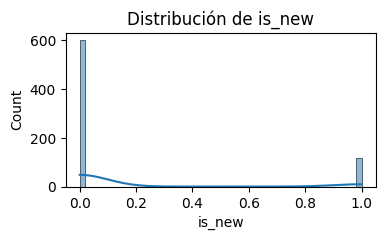

In [7]:
hist_plot(casas_train_df, 'is_new')

In [8]:
if any(casas_train_df['age'] >= 30) or any(casas_val_df['age'] >= 30) or any(casas_test_df['age'] >= 30):
    casas_train_df['is_old'] = (casas_train_df['age'] >= 30).astype(int)
    casas_val_df['is_old'] = (casas_val_df['age'] >= 30).astype(int)
    casas_test_df['is_old'] = (casas_test_df['age'] >= 30).astype(int)
    
    casas_train_df[[ 'age', 'is_old']].head()


In [9]:
median_area = casas_train_df['area'].median()

casas_train_df['is_big'] = (casas_train_df['area'] > median_area).astype(int)
casas_val_df['is_big'] = (casas_val_df['area'] > median_area).astype(int)
casas_test_df['is_big'] = (casas_test_df['area'] > median_area).astype(int)

casas_train_df[['area', 'is_big']].head()


,area,is_big
0,81.011529,0
1,99.963768,1
2,137.000000,1
3,71.999926,0
4,154.000000,1


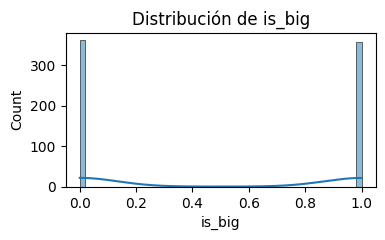

In [10]:
hist_plot(casas_train_df, 'is_big')

In [11]:
# Evitar la división por cero
epsilon = 1e-6  

# m2_per_room: Metros cuadrados por habitación (más grande => más espacio por cuarto)
casas_train_df['m2_per_room'] = casas_train_df['area'] / (casas_train_df['rooms'] + epsilon)
casas_val_df['m2_per_room'] = casas_val_df['area'] / (casas_val_df['rooms'] + epsilon)
casas_test_df['m2_per_room'] = casas_test_df['area'] / (casas_test_df['rooms'] + epsilon)

# Limitar valores extremos al percentil 1 y 99
m2_per_room_limits = casas_train_df['m2_per_room'].quantile([0.01, 0.99])

casas_train_df['m2_per_room'] = casas_train_df['m2_per_room'].clip(*m2_per_room_limits)

casas_train_df[[ 'area', 'rooms', 'm2_per_room']].head()


,area,rooms,m2_per_room
0,81.011529,2.0,40.505744
1,99.963768,3.0,33.321245
2,137.000000,4.0,34.249991
3,71.999926,2.0,35.999945
4,154.000000,4.0,38.499990


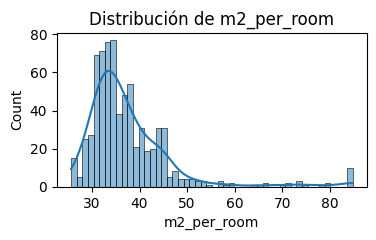

In [12]:
hist_plot(casas_train_df, 'm2_per_room')

In [13]:
# Evitar división por cero con un pequeño epsilon
epsilon = 1e-6

# Crear la nueva feature en cada conjunto de datos
casas_train_df['distance_per_age'] = casas_train_df['dist_to_cluster_centroid'] / (casas_train_df['age'] + epsilon)
casas_val_df['distance_per_age'] = casas_val_df['dist_to_cluster_centroid'] / (casas_val_df['age'] + epsilon)
casas_test_df['distance_per_age'] = casas_test_df['dist_to_cluster_centroid'] / (casas_test_df['age'] + epsilon)

casas_train_df[['dist_to_cluster_centroid', 'age', 'distance_per_age']].head()

,dist_to_cluster_centroid,age,distance_per_age
0,1.064317,11.0,0.096756
1,0.588810,7.0,0.084116
2,5.890130,10.0,0.589013
3,3.772768,10.0,0.377277
4,5.341236,16.0,0.333827


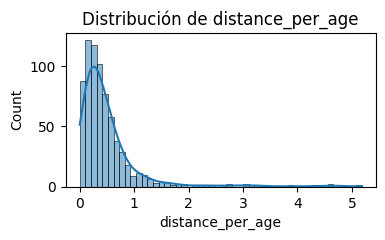

In [14]:
hist_plot(casas_train_df, 'distance_per_age')

In [15]:
casas_train_df['log_area_plus_1'] = np.log(casas_train_df['area'] + 1)
casas_val_df['log_area_plus_1'] = np.log(casas_val_df['area'] + 1)
casas_test_df['log_area_plus_1'] = np.log(casas_test_df['area'] + 1)

casas_train_df[['area', 'log_area_plus_1']].head()

,area,log_area_plus_1
0,81.011529,4.406860
1,99.963768,4.614762
2,137.000000,4.927254
3,71.999926,4.290458
4,154.000000,5.043425


si una casa es más nueva que la mediana de su zona.

In [16]:
median_age_per_cluster = casas_train_df.groupby('cluster_id')['age'].median()

casas_train_df['is_new_relative'] = (casas_train_df['age'] < casas_train_df['cluster_id'].map(median_age_per_cluster)).astype(int)
casas_val_df['is_new_relative'] = (casas_val_df['age'] < casas_val_df['cluster_id'].map(median_age_per_cluster)).astype(int)
casas_test_df['is_new_relative'] = (casas_test_df['age'] < casas_test_df['cluster_id'].map(median_age_per_cluster)).astype(int)

casas_train_df[['age', 'cluster_id', 'is_new_relative']].head()

,age,cluster_id,is_new_relative
0,11.0,1,0
1,7.0,1,1
2,10.0,0,1
3,10.0,1,0
4,16.0,0,0


In [17]:
casas_train_df['log_m2_per_room'] = np.log(casas_train_df['m2_per_room'] + 1)
casas_val_df['log_m2_per_room'] = np.log(casas_val_df['m2_per_room'] + 1)
casas_test_df['log_m2_per_room'] = np.log(casas_test_df['m2_per_room'] + 1)

casas_train_df[['m2_per_room', 'log_m2_per_room']].head()

,m2_per_room,log_m2_per_room
0,40.505744,3.725832
1,33.321245,3.535765
2,34.249991,3.562465
3,35.999945,3.610916
4,38.499990,3.676300


Ángulo Geográfico: geo_angle = arctan(lat / lon)

🔹 Puede capturar la orientación relativa de la casa en el espacio, lo que podría estar relacionado con la distribución urbana.

In [18]:
casas_train_df['geo_angle'] = np.arctan(casas_train_df['lat'] / (casas_train_df['lon'] + 1e-6))
casas_val_df['geo_angle'] = np.arctan(casas_val_df['lat'] / (casas_val_df['lon'] + 1e-6))
casas_test_df['geo_angle'] = np.arctan(casas_test_df['lat'] / (casas_test_df['lon'] + 1e-6))


rooms / sqrt(area) cuán densamente están distribuidas las habitaciones.

In [19]:
casas_train_df['room_density'] = casas_train_df['rooms'] / np.sqrt(casas_train_df['area'] + 1e-6)
casas_val_df['room_density'] = casas_val_df['rooms'] / np.sqrt(casas_val_df['area'] + 1e-6)
casas_test_df['room_density'] = casas_test_df['rooms'] / np.sqrt(casas_test_df['area'] + 1e-6)


age_2, area_2, distance_to_center_2

In [20]:
casas_train_df['age_2'] = casas_train_df['age'] ** 2
casas_val_df['age_2'] = casas_val_df['age'] ** 2
casas_test_df['age_2'] = casas_test_df['age'] ** 2

casas_train_df['area_2'] = casas_train_df['area'] ** 2
casas_val_df['area_2'] = casas_val_df['area'] ** 2
casas_test_df['area_2'] = casas_test_df['area'] ** 2

casas_train_df['distance_to_center_2'] = casas_train_df['dist_to_cluster_centroid'] ** 2
casas_val_df['distance_to_center_2'] = casas_val_df['dist_to_cluster_centroid'] ** 2
casas_test_df['distance_to_center_2'] = casas_test_df['dist_to_cluster_centroid'] ** 2


rooms * age: Captura si casas con más habitaciones tienden a ser más viejas.
✅ rooms * distance: Captura si casas más alejadas suelen ser más grandes o más chicas.

In [21]:

casas_train_df['rooms_distance_interaction'] = casas_train_df['rooms'] * casas_train_df['dist_to_cluster_centroid']
casas_val_df['rooms_distance_interaction'] = casas_val_df['rooms'] * casas_val_df['dist_to_cluster_centroid']
casas_test_df['rooms_distance_interaction'] = casas_test_df['rooms'] * casas_test_df['dist_to_cluster_centroid']

casas_train_df['rooms_age_interaction'] = casas_train_df['rooms'] * casas_train_df['age']
casas_val_df['rooms_age_interaction'] = casas_val_df['rooms'] * casas_val_df['age']
casas_test_df['rooms_age_interaction'] = casas_test_df['rooms'] * casas_test_df['age']

In [22]:
from src.utils import select_features

In [23]:
features_f = ["area", "is_house", "has_pool", "lat", "lon", "age", "rooms", "cluster_id", "dist_to_cluster_centroid", "pca_latlon_1", 
            "geo_angle", "is_near_centroid", "is_new", "is_big", "is_new_relative", "m2_per_room", "room_density", "distance_per_age", 
            "rooms_distance_interaction", "rooms_age_interaction", "log_area_plus_1", "log_m2_per_room", "age_2", "area_2", "distance_to_center_2"] 

relevant_features_f = ["area", "is_house", "age", "rooms", "cluster_id", "dist_to_cluster_centroid", 
                     "is_near_centroid", "is_new", "is_big", "is_new_relative", "m2_per_room", "room_density", 
                     "distance_per_age", "rooms_distance_interaction", "rooms_age_interaction", "log_area_plus_1", "log_m2_per_room", 
                     "age_2", "area_2", "distance_to_center_2"] 

to_standarize = ["age", "rooms", "log_area_plus_1", "room_density"]

to_scale = ["area", "dist_to_cluster_centroid", "pca_latlon_1", "geo_angle", "m2_per_room", "room_density", "distance_per_age", 
            "rooms_distance_interaction", "rooms_age_interaction", "log_area_plus_1", "log_m2_per_room", "age_2", "area_2", "distance_to_center_2"]

train_path_featured = dir_base + "casas_train_featured.csv"
validation_path_featured = dir_base + "casas_val_featured.csv"    
test_path_featured = dir_base + "casas_test_featured.csv"

X_train_f, y_train_f = load_data(train_path_featured, None, features_f, target)
X_val_f, y_val_f = load_data(validation_path_featured, None, features_f, target)
X_test_f, y_test_f = load_data(test_path_featured, None, features_f, target)

X_train_subset_f, X_val_subset_f, X_test_subset_f = select_features(relevant_features_f, features_f, X_train_f, X_val_f, X_test_f)

model_f_pinv = LinearRegression(X_train_subset_f, y_train_f, X_val_subset_f, y_val_f, relevant_features_f, False, None, to_scale, to_standarize)
model_f_pinv.entrenar_pseudoinversa()
model_f_pinv.evaluar(X_test_subset_f, y_test_f)

Error cuadrático medio (MSE) en test: 8513.5565


8513.556460158168

In [ ]:
from Tissera_AnaPaula_TP1.src.feature_engineering import generate_power_features

train_power_features = generate_power_features(casas_train_df)
val_power_features = generate_power_features(casas_val_df)
test_power_features = generate_power_features(casas_test_df)

casas_train_df = pd.concat([casas_train_df, train_power_features], axis=1)
casas_val_df = pd.concat([casas_val_df, val_power_features], axis=1)
casas_test_df = pd.concat([casas_test_df, test_power_features], axis=1)


features_43 = [col for col in casas_train_df.columns if col != "price"]

# Imprimir la lista resultante
print(features_43)

model_f_pinv = LinearRegression(X_train_subset_f, y_train_f, X_val_subset_f, y_val_f, relevant_features_f, False, None, to_scale, to_standarize)
model_f_pinv.entrenar_pseudoinversa()
model_f_pinv.evaluar(X_test_subset_f, y_test_f)

ImportError: cannot import name 'generate_power_features' from 'src.feature_engenieering' (c:\Users\anapt\Repositorios\ML-DL\Tissera_AnaPaula_TP1\src\feature_engenieering.py)